# Fixed two-component, AIC-selected, and BIC-selected GMM panels

This notebook compares the original two-component GMM with class-specific component counts selected independently by AIC and BIC in Table S5. Non-GMM cohorts are retained from the final cached analysis so the comparison isolates the effect of changing $K$.

## Setup

The final analysis uses 50 repeated origin-classification runs and 20 utility runs. Set the two repeat counts lower for a quick preview.

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

repo_root = Path.cwd()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parents[1]
pkg_root = repo_root / 'data_synthesis'
if str(pkg_root) not in sys.path:
    sys.path.insert(0, str(pkg_root))

notebooks_dir = pkg_root / 'notebooks'
if str(notebooks_dir) not in sys.path:
    sys.path.insert(0, str(notebooks_dir))

from models.gmm import AIC_COMPONENTS_BY_DATASET, BIC_COMPONENTS_BY_DATASET
from src import original_paper_followup as followup
from src.revision import data_io
import regenerate_aic_gmm_panels as workflow

followup = importlib.reload(followup)
workflow = importlib.reload(workflow)

SEED = 42
RUN_MODE = 'preview'  # change to 'final' for the manuscript run
AUC_REPEATS = {'preview': 5, 'final': 50}[RUN_MODE]
UTILITY_REPEATS = {'preview': 3, 'final': 20}[RUN_MODE]
export_dir = pkg_root / 'notebooks' / 'followup_exports'
export_dir.mkdir(parents=True, exist_ok=True)

## Table S5 model specification

Each tuple lists the component counts for class 0 and class 1. The generator retains the full-covariance specification used for the candidate models.

In [2]:
component_table = pd.DataFrame([
    {
        'dataset': dataset,
        'AIC class 0 K': AIC_COMPONENTS_BY_DATASET[dataset][0],
        'AIC class 1 K': AIC_COMPONENTS_BY_DATASET[dataset][1],
        'BIC class 0 K': BIC_COMPONENTS_BY_DATASET[dataset][0],
        'BIC class 1 K': BIC_COMPONENTS_BY_DATASET[dataset][1],
    }
    for dataset in AIC_COMPONENTS_BY_DATASET
])
display(component_table)

,dataset,AIC class 0 K,AIC class 1 K,BIC class 0 K,BIC class 1 K
0,Breast Cancer,5,5,2,2
1,Diabetes,5,5,4,2
2,HIV,2,3,2,2


## Load data and construct AIC- and BIC-selected GMM cohorts

The cached final cohorts are copied, then only the AIC- and BIC-selected GMM cohorts for each dataset are regenerated.

In [3]:
datasets, dataset_summary = data_io.initialize_datasets()
cohorts = workflow.build_aic_cohorts(datasets)
bic_cohorts = workflow.build_bic_cohorts(datasets)
gmm_only = {
    dataset: {'GMM': method_data['GMM']}
    for dataset, method_data in cohorts.items()
}
bic_gmm_only = {
    dataset: {'GMM': method_data['GMM']}
    for dataset, method_data in bic_cohorts.items()
}
display(dataset_summary)

,dataset,samples,features,class_0,class_1
0,HIV,91,63,23,68
1,Breast Cancer,569,30,212,357
2,Diabetes,768,8,500,268


## Recompute GMM-dependent metrics

Only the AIC- and BIC-selected GMM rows are recomputed; cached results supply the fixed two-component baseline and unchanged generators. This cell is the computationally expensive part of the notebook.

In [4]:
gmm_auc = followup.compute_origin_auc(
    datasets, gmm_only, repeats=AUC_REPEATS, seed=SEED
)
auc_runs = workflow.replace_method_rows(
    workflow.load_cache('origin_auc'), gmm_auc
)

gmm_kld = followup.compute_feature_kld_table(datasets, gmm_only)
feature_kld = workflow.replace_method_rows(
    workflow.load_cache('feature_kld'), gmm_kld
)

gmm_marginal = followup.compute_marginal_tests(datasets, gmm_only)
marginal_tests = workflow.replace_method_rows(
    workflow.load_cache('marginal_tests'), gmm_marginal
)

gmm_tstr = followup.compute_tstr_runs(
    datasets, gmm_only, repeats=UTILITY_REPEATS, seed=SEED
)
tstr_runs = workflow.replace_method_rows(
    workflow.load_cache('tstr_runs'), gmm_tstr
)
tstr_runs['utility_gap_abs'] = (
    tstr_runs['trtr_f1'] - tstr_runs['tstr_f1']
).abs()

bic_auc = followup.compute_origin_auc(
    datasets, bic_gmm_only, repeats=AUC_REPEATS, seed=SEED
)
bic_kld = followup.compute_feature_kld_table(datasets, bic_gmm_only)
bic_tstr = followup.compute_tstr_runs(
    datasets, bic_gmm_only, repeats=UTILITY_REPEATS, seed=SEED
)
bic_tstr['utility_gap_abs'] = (
    bic_tstr['trtr_f1'] - bic_tstr['tstr_f1']
).abs()

auc_summary = (
    auc_runs.groupby(['dataset', 'method'])['separability_auc']
    .agg(mean='mean', sd='std')
    .reset_index()
)
display(auc_summary[auc_summary['method'] == 'GMM'])

,dataset,method,mean,sd
3,Breast Cancer,GMM,0.991244,0.001089
9,Diabetes,GMM,0.972192,0.004168
15,HIV,GMM,1.000000,0.000000


## Figure 1: origin AUC, feature KLD, and utility gap

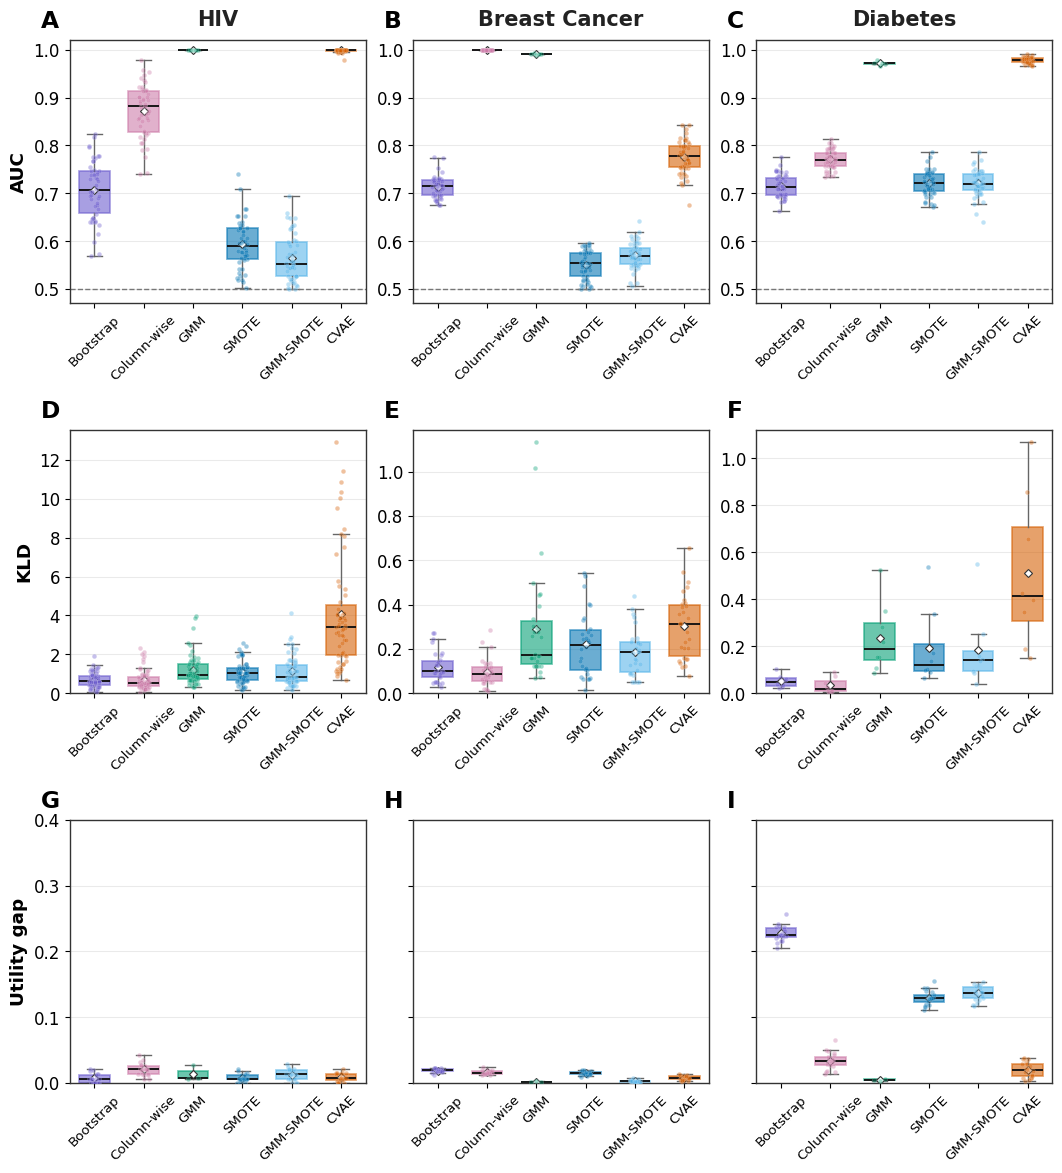

In [5]:
fig1 = followup.plot_figure1_fidelity_grid(
    auc_runs,
    feature_kld,
    marginal_tests,
    tstr_runs,
    dataset_order=list(datasets),
    method_order=followup.METHOD_ORDER,
    jitter_seed=SEED,
)
display(fig1)
plt.close(fig1)

## Figure 2: PCA examples and RF origin separability

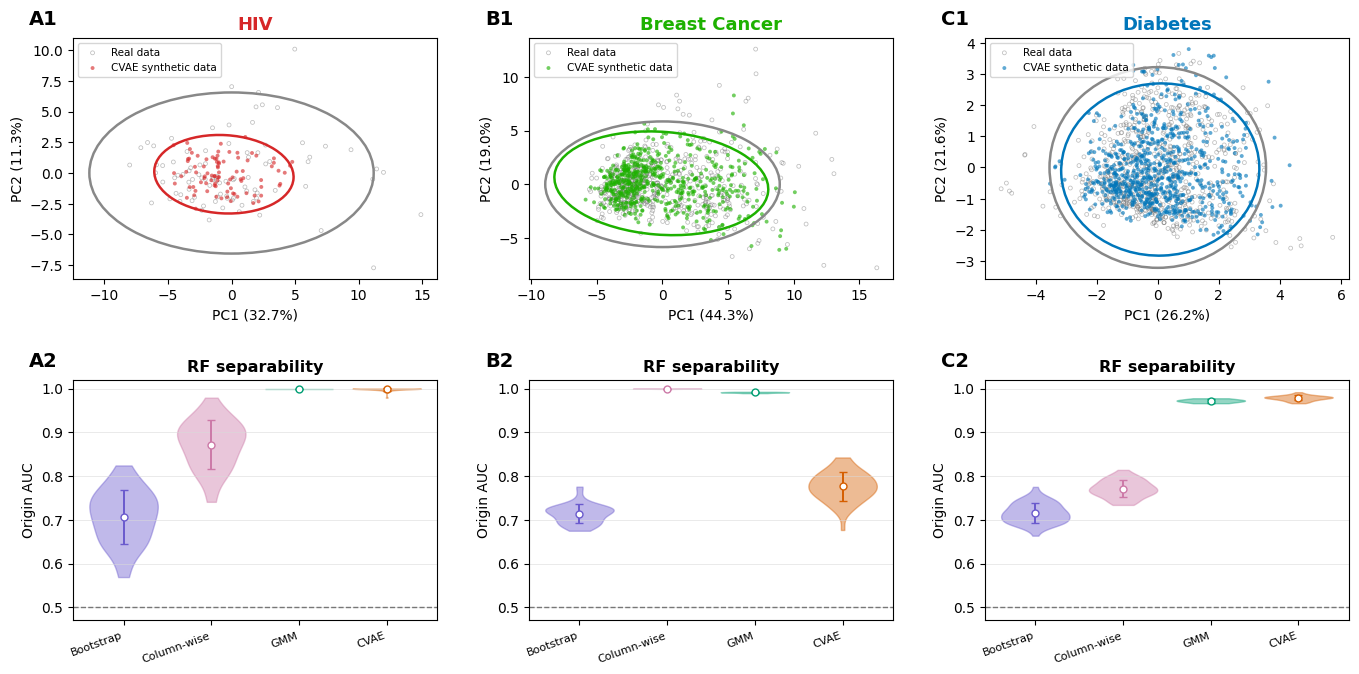

In [6]:
fig2 = workflow.plot_pca_rf_overview(datasets, cohorts, auc_runs)
display(fig2)
plt.close(fig2)

## Export figures and supporting tables

In [7]:
figure1_path = export_dir / 'figure1_aic_gmm_auc_kld_utility.png'
figure2_path = export_dir / 'figure2_aic_gmm_pca_rf_auc.png'

fig1 = followup.plot_figure1_fidelity_grid(
    auc_runs, feature_kld, marginal_tests, tstr_runs,
    dataset_order=list(datasets), method_order=followup.METHOD_ORDER,
    jitter_seed=SEED,
)
fig2 = workflow.plot_pca_rf_overview(datasets, cohorts, auc_runs)
fig1.savefig(figure1_path, dpi=300, bbox_inches='tight', facecolor='white')
fig2.savefig(figure2_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig1)
plt.close(fig2)

component_table.to_csv(export_dir / 'aic_gmm_components.csv', index=False)
auc_runs.to_csv(export_dir / 'aic_gmm_origin_auc_runs.csv', index=False)
auc_summary.to_csv(export_dir / 'aic_gmm_auc_summary.csv', index=False)
feature_kld.to_csv(export_dir / 'aic_gmm_feature_kld.csv', index=False)
tstr_runs.to_csv(export_dir / 'aic_gmm_tstr_runs.csv', index=False)

print(f'Saved {figure1_path}')
print(f'Saved {figure2_path}')

Saved C:\Users\tonyt\Desktop\distinguishable_data\data_synthesis\notebooks\followup_exports\figure1_aic_gmm_auc_kld_utility.png
Saved C:\Users\tonyt\Desktop\distinguishable_data\data_synthesis\notebooks\followup_exports\figure2_aic_gmm_pca_rf_auc.png


## Comparison of fixed two-component, AIC-selected, and BIC-selected GMMs

A lower origin AUC is better, with 0.5 indicating chance-level distinguishability. A smaller absolute utility gap and smaller KLD are also better.

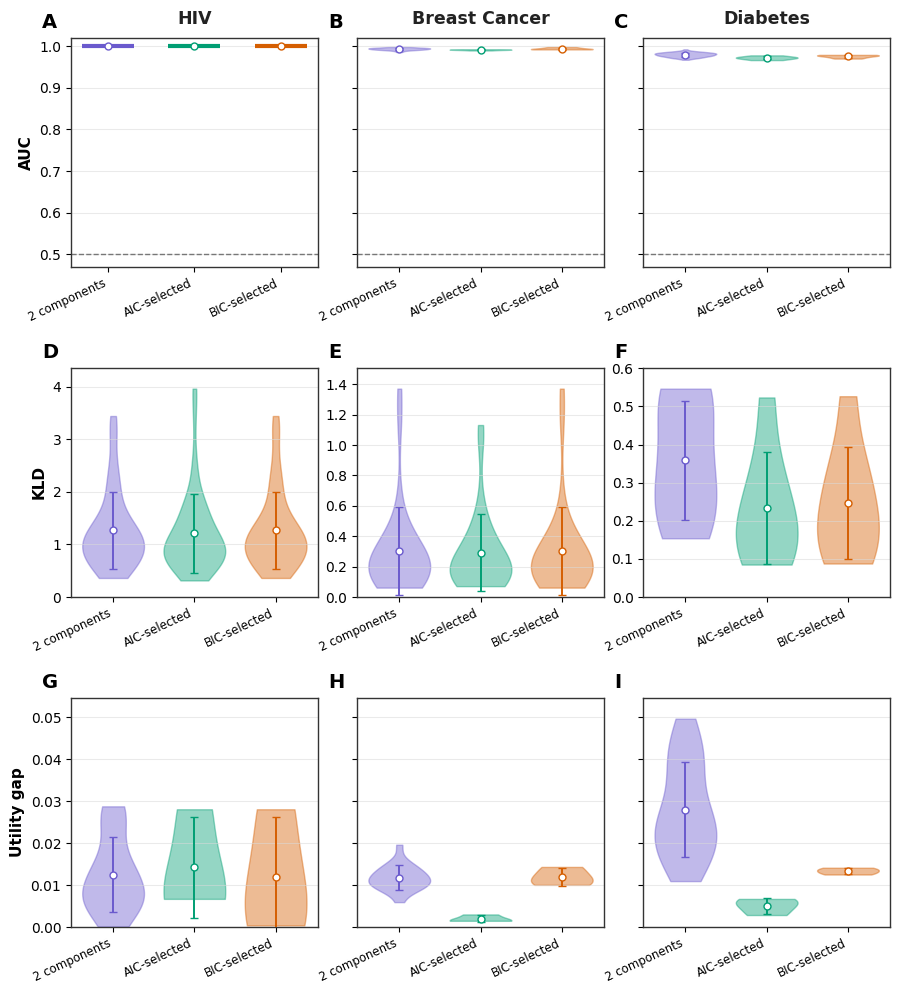

Saved C:\Users\tonyt\Desktop\distinguishable_data\data_synthesis\notebooks\followup_exports\gmm_fixed2_aic_bic_auc_kld_utility.png


Dataset,GMM specification,$K_0/K_1$,AUC,KLD,Utility gap
HIV,2 components,2/2,$1.000 \pm 0.000$,$1.270 \pm 0.732$,$0.012 \pm 0.009$
HIV,AIC-selected,2/3,$1.000 \pm 0.000$,$1.208 \pm 0.756$,$0.014 \pm 0.012$
HIV,BIC-selected,2/2,$1.000 \pm 0.000$,$1.270 \pm 0.732$,$0.012 \pm 0.014$
Breast Cancer,2 components,2/2,$0.993 \pm 0.003$,$0.303 \pm 0.292$,$0.012 \pm 0.003$
Breast Cancer,AIC-selected,5/5,$0.991 \pm 0.001$,$0.290 \pm 0.254$,$0.002 \pm 0.001$
Breast Cancer,BIC-selected,2/2,$0.994 \pm 0.002$,$0.303 \pm 0.292$,$0.012 \pm 0.002$
Diabetes,2 components,2/2,$0.980 \pm 0.005$,$0.359 \pm 0.156$,$0.028 \pm 0.011$
Diabetes,AIC-selected,5/5,$0.972 \pm 0.004$,$0.235 \pm 0.147$,$0.005 \pm 0.002$
Diabetes,BIC-selected,4/2,$0.976 \pm 0.004$,$0.247 \pm 0.146$,$0.013 \pm 0.001$


\begin{table}[t]
\caption{Comparison of fixed two-component GMMs with class-specific component counts selected by AIC and BIC. Values are mean $\pm$ standard deviation.}
\label{tab:gmm_component_sensitivity}
\begin{tabular}{lllccc}
\toprule
Dataset & GMM specification & $K_0/K_1$ & AUC & KLD & Utility gap \\
\midrule
HIV & 2 components & 2/2 & $1.000 \pm 0.000$ & $1.270 \pm 0.732$ & $0.012 \pm 0.009$ \\
HIV & AIC-selected & 2/3 & $1.000 \pm 0.000$ & $1.208 \pm 0.756$ & $0.014 \pm 0.012$ \\
HIV & BIC-selected & 2/2 & $1.000 \pm 0.000$ & $1.270 \pm 0.732$ & $0.012 \pm 0.014$ \\
Breast Cancer & 2 components & 2/2 & $0.993 \pm 0.003$ & $0.303 \pm 0.292$ & $0.012 \pm 0.003$ \\
Breast Cancer & AIC-selected & 5/5 & $0.991 \pm 0.001$ & $0.290 \pm 0.254$ & $0.002 \pm 0.001$ \\
Breast Cancer & BIC-selected & 2/2 & $0.994 \pm 0.002$ & $0.303 \pm 0.292$ & $0.012 \pm 0.002$ \\
Diabetes & 2 components & 2/2 & $0.980 \pm 0.005$ & $0.359 \pm 0.156$ & $0.028 \pm 0.011$ \\
Diabetes & AIC-selected & 5/5 

1194

In [8]:
old_auc = workflow.load_cache('origin_auc')
old_tstr = workflow.load_cache('tstr_runs').copy()
old_kld = workflow.load_cache('feature_kld')
old_tstr['utility_gap_abs'] = (old_tstr['trtr_f1'] - old_tstr['tstr_f1']).abs()

specifications = ['2 components', 'AIC-selected', 'BIC-selected']
specification_colors = {
    '2 components': '#6A5ACD',
    'AIC-selected': '#009E73',
    'BIC-selected': '#D55E00',
}
metric_sources = {
    'AUC': ((old_auc, auc_runs, bic_auc), 'separability_auc'),
    'KLD': ((old_kld, feature_kld, bic_kld), 'kld'),
    'Utility gap': ((old_tstr, tstr_runs, bic_tstr), 'utility_gap_abs'),
}
utility_tables, utility_column = metric_sources['Utility gap']
utility_values = np.concatenate([
    table.query("method == 'GMM'")[utility_column].dropna().to_numpy(dtype=float)
    for table in utility_tables
])
utility_upper = 1.10 * max(
    float(np.max(utility_values)),
    float(np.mean(utility_values) + np.std(utility_values, ddof=1)),
)

# Match the existing fidelity panels: dataset columns, metric rows,
# translucent violins, and mean +/- SD markers.
# Keep a common scale for AUC, but let each KLD panel use its own range.
# HIV has a much wider KLD distribution, which otherwise compresses the
# Breast Cancer and Diabetes violins against zero.
fig, axes = plt.subplots(3, 3, figsize=(9.1, 10.4), squeeze=False, sharey=False)
for row, (metric, (specification_tables, value_column)) in enumerate(metric_sources.items()):
    for col, dataset in enumerate(datasets):
        ax = axes[row, col]
        values = []
        for table in specification_tables:
            values.append(
                table.query("dataset == @dataset and method == 'GMM'")[value_column]
                .dropna().to_numpy(dtype=float)
            )

        for position, (specification, method_values) in enumerate(zip(specifications, values)):
            color = specification_colors[specification]
            if np.ptp(method_values) > 0:
                violin = ax.violinplot(
                    [method_values], positions=[position], widths=0.76,
                    showmeans=False, showmedians=False, showextrema=False,
                )
                body = violin['bodies'][0]
                body.set_facecolor(color)
                body.set_edgecolor(color)
                body.set_alpha(0.42)
            else:
                ax.hlines(method_values[0], position - 0.30, position + 0.30, color=color, linewidth=3)

            mean = float(np.mean(method_values))
            sd = float(np.std(method_values, ddof=1))
            ax.errorbar(
                position, mean, yerr=sd, fmt='o', markersize=5,
                color=color, markerfacecolor='white', capsize=3,
                linewidth=1.4, zorder=4,
            )

        if row == 0:
            ax.axhline(0.5, color='#777777', linestyle='--', linewidth=1.0)
            ax.set_ylim(0.47, 1.02)
            ax.tick_params(axis='y', labelleft=col == 0)
            ax.set_title(
                dataset, color='#222222',
                fontsize=12.5, weight='bold', pad=10,
            )
        elif row == 1:
            panel_max = max(
                max(float(np.max(v)), float(np.mean(v) + np.std(v, ddof=1)))
                for v in values
            )
            ax.set_ylim(0.0, panel_max * 1.10 if panel_max > 0 else 1.0)
        else:
            ax.set_ylim(0.0, utility_upper)
            ax.tick_params(axis='y', labelleft=col == 0)
        if col == 0:
            ax.set_ylabel(metric, fontsize=11, weight='semibold')
        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(specifications, rotation=25, ha='right', fontsize=8.5)
        ax.grid(axis='y', color='#D9D9D9', linewidth=0.75, alpha=0.55)
        ax.tick_params(direction='out', width=0.8)
        for spine in ax.spines.values():
            spine.set_linewidth(1.0)
            spine.set_color('#333333')

fig.subplots_adjust(
    left=0.09, right=0.99, top=0.955, bottom=0.10,
    wspace=0.16, hspace=0.44,
)
for letter, ax in zip('ABCDEFGHI', axes.ravel()):
    position = ax.get_position()
    fig.text(
        position.x0 - 0.032, position.y1 + 0.006, letter,
        ha='left', va='bottom', fontsize=14, weight='bold',
    )
comparison_figure_path = export_dir / 'gmm_fixed2_aic_bic_auc_kld_utility.png'
fig.savefig(comparison_figure_path, dpi=300, bbox_inches='tight', facecolor='white')
display(fig)
plt.close(fig)
print(f'Saved {comparison_figure_path}')

# Compact summary table and copy-ready Overleaf output.
comparison_rows = []
for dataset in datasets:
    for specification, table_index in zip(specifications, (0, 1, 2)):
        row_values = {}
        for metric, (specification_tables, value_column) in metric_sources.items():
            table = specification_tables[table_index]
            metric_values = table.query("dataset == @dataset and method == 'GMM'")[value_column].dropna()
            row_values[metric] = f'${metric_values.mean():.3f} \\pm {metric_values.std(ddof=1):.3f}$'
        component_counts = {
            '2 components': (2, 2),
            'AIC-selected': AIC_COMPONENTS_BY_DATASET[dataset],
            'BIC-selected': BIC_COMPONENTS_BY_DATASET[dataset],
        }
        k0, k1 = component_counts[specification]
        comparison_rows.append({
            'Dataset': dataset, 'GMM specification': specification,
            '$K_0/K_1$': f'{k0}/{k1}', **row_values,
        })

comparison_table = pd.DataFrame(comparison_rows)
display(comparison_table.style.hide(axis='index'))
latex_table = comparison_table.to_latex(
    index=False, escape=False, position='t',
    caption=(
        'Comparison of fixed two-component GMMs with class-specific component '
        'counts selected by AIC and BIC. Values are mean $\\pm$ standard deviation.'
    ),
    label='tab:gmm_component_sensitivity', column_format='lllccc',
)
print(latex_table)
comparison_table.to_csv(export_dir / 'gmm_fixed2_aic_bic_comparison.csv', index=False)
(export_dir / 'gmm_fixed2_aic_bic_comparison.tex').write_text(latex_table, encoding='utf-8')